In [1]:
import os, warnings
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import pyomo.environ as pyo
from pyomo.opt import SolverStatus, TerminationCondition
import matplotlib.pyplot as plt
from itertools import product as iterproduct
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings("ignore", category=FutureWarning)

# ── Reproducibility seeds ────────────────────────────────────────
import random
GLOBAL_SEED = 42
random.seed(GLOBAL_SEED)
np.random.seed(GLOBAL_SEED)
torch.manual_seed(GLOBAL_SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

BASE_DIR  = os.getcwd()
PLOT_DIR  = os.path.join(BASE_DIR, "results", "plots")
CACHE_DIR = os.path.join(BASE_DIR, "data_cache")
RESULT_DIR = os.path.join(BASE_DIR, "results")
for d in (PLOT_DIR, CACHE_DIR, RESULT_DIR):
    os.makedirs(d, exist_ok=True)

print("Plots   →", PLOT_DIR)
print("Cache   →", CACHE_DIR)
print("Results →", RESULT_DIR)


Plots   → d:\battery-storage-optimization-energy-ancillary\results\plots
Cache   → d:\battery-storage-optimization-energy-ancillary\data_cache
Results → d:\battery-storage-optimization-energy-ancillary\results


## Section 1 — Physical & Financial Parameters

In [2]:
# ── Battery & market parameters ──────────────────────────────────────────────
# All values are defined here directly — no external params.py needed.
# Change these to match your battery spec and market.

MAX_CHARGE_MW    = 10.0   # Maximum charge power   (MW)
MAX_DISCHARGE_MW = 10.0   # Maximum discharge power (MW)
CAPACITY_MWH     = 10.0   # Battery energy capacity (MWh)  ← set independently
EFFICIENCY       = 0.90   # One-way round-trip efficiency
TRANSACTION_FEE  = 0.5    # Transaction fee         ($/MWh)
DEGRADATION_COST = 2.5    # Degradation cost        ($/MWh)

# Shorter aliases used inside the optimiser
mcp = MAX_CHARGE_MW
mdp = MAX_DISCHARGE_MW
e   = EFFICIENCY
fee = TRANSACTION_FEE
degradation_cost = DEGRADATION_COST

print(f"Battery: {CAPACITY_MWH} MWh | charge {mcp} MW | discharge {mdp} MW")
print(f"Costs:   efficiency {e} | fee ${fee}/MWh | degradation ${degradation_cost}/MWh")


Battery: 10.0 MWh | charge 10.0 MW | discharge 10.0 MW
Costs:   efficiency 0.9 | fee $0.5/MWh | degradation $2.5/MWh


## Section 2 — VAE Hyper-parameters

In [3]:
VAE_EPOCHS     = 50
VAE_BATCH      = 16
VAE_LR         = 1e-3
VAE_SEQ_LEN    = 24       # one sequence = one 24-hour day
VAE_LATENT_DIM = 8
VAE_TRAIN_FRAC = 0.80
VALID_MODES    = {"baseline", "penalised", "opportunistic"}


## Section 3 — Data Loading (Cache-first)
Loads from `data_cache/*.csv.gz` on every run after the first fetch. Delete those files to force a re-fetch.

In [4]:
CACHE_CLEAN = os.path.join(CACHE_DIR, "merged_df_clean.csv.gz")
CACHE_SPIKE = os.path.join(CACHE_DIR, "merged_df_spike.csv.gz")
_DT_COLS    = ["datetime"]

def _save_df(df, path):
    df.to_csv(path, index=False, compression="gzip")

def _load_df(path):
    df = pd.read_csv(path, compression="gzip")
    for col in _DT_COLS:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col])
    return df

def load_or_fetch():
    if os.path.exists(CACHE_CLEAN) and os.path.exists(CACHE_SPIKE):
        print("[CACHE] Loading from compressed CSV cache …")
        clean = _load_df(CACHE_CLEAN)
        spike = _load_df(CACHE_SPIKE)
        print(f"  clean: {clean.shape}  spike: {spike.shape}")
        return clean, spike

    print("[FETCH] Cache not found — importing from pull_prices …")
    try:
        from pull_prices import merged_df_clean as _c, merged_df_spike as _s
    except ImportError as exc:
        raise ImportError(
            "pull_prices.py not found and no cache exists. "
            "Place pull_prices.py next to this notebook, or put the "
            "pre-fetched CSV files in: " + CACHE_DIR
        ) from exc

    if _c is None or _s is None:
        raise ValueError("pull_prices returned None — check API credentials.")

    print("[CACHE] Saving …")
    _save_df(_c, CACHE_CLEAN)
    _save_df(_s, CACHE_SPIKE)
    print(f"  Saved: {CACHE_CLEAN}\n  Saved: {CACHE_SPIKE}")
    return _c.copy(), _s.copy()

merged_df_clean, merged_df_spike = load_or_fetch()

assert "SP15" in merged_df_clean.columns, "SP15 missing in clean data"
assert "SP15" in merged_df_spike.columns, "SP15 missing in spike data"
print("\nClean:", merged_df_clean.shape, "  Spike:", merged_df_spike.shape)
print(merged_df_clean.head())


[CACHE] Loading from compressed CSV cache …
  clean: (77832, 9)  spike: (77832, 9)

Clean: (77832, 9)   Spike: (77832, 9)
             datetime              node       SP15  NonSpin  RegDown  \
0 2023-01-12 08:00:00  TH_NP15_GEN-APND  137.79688     0.27     7.99   
1 2023-01-12 08:00:00  TH_SP15_GEN-APND  138.44933     0.27     7.99   
2 2023-01-12 08:00:00  TH_ZP26_GEN-APND  135.07355     0.27     7.99   
3 2023-01-12 09:00:00  TH_NP15_GEN-APND  132.21107     0.27     7.99   
4 2023-01-12 09:00:00  TH_SP15_GEN-APND  132.93228     0.27     7.99   

   Regulation Mileage Down  Regulation Mileage Up     RegUp      Spin  
0                      0.0                    0.0  21.00347  19.92778  
1                      0.0                    0.0  21.00347  19.92778  
2                      0.0                    0.0  21.00347  19.92778  
3                      0.0                    0.0   7.53989   7.52989  
4                      0.0                    0.0   7.53989   7.52989  


## Section 4 — Inject Synthetic Non-Reverting Spikes
Adds short-duration price spikes that **don't revert** to the attack dataset. These create genuine misclassification pressure at high λ, producing the realistic concave profit curve expected in sensitivity analysis.

In [5]:
def inject_fake_spikes(df, num_spikes=8, spike_duration=4, spike_magnitude=1.8,
                       non_revert_fraction=0.4, random_seed=42, return_mask=False):
    """
    Inject synthetic spikes into the attack dataset.
    - Reverting spikes  (60 %): sharp up, then fast reversion
    - Non-reverting (40 %): plateau/slow decay

    Args:
        return_mask: if True, also return a boolean array marking injected hours.
                     Use this for honest ground-truth labelling in evaluate_classifier.
    """
    # Use a local RNG — avoids resetting the global numpy seed and
    # creating hidden ordering dependencies between cells.
    rng = np.random.default_rng(random_seed)

    df = df.copy().reset_index(drop=True)
    n  = len(df)
    baseline = df["SP15"].median()
    safe_idx = np.arange(0, max(n - 7 * 24, 1))
    starts   = sorted(rng.choice(safe_idx,
                      size=min(num_spikes, len(safe_idx)), replace=False).tolist())

    spike_hours = []  # track every injected hour for ground-truth mask

    for start in starts:
        will_revert = rng.random() > non_revert_fraction
        # Fix: ensure high > low for randint even when spike_duration == 1
        dur  = int(rng.integers(2, max(3, spike_duration + 1)))
        end  = min(start + dur, n - 1)
        # Fix: clip upper bound to spike_magnitude * 1.1 so the requested
        # magnitude is actually injected (old code hard-capped at 4.0,
        # making 5× and 8× configs identical in the robustness sweep).
        mag  = float(np.clip(
            spike_magnitude + rng.normal(0, 0.1 * spike_magnitude),
            1.2, spike_magnitude * 1.1
        ))

        spike_hours.extend(range(start, end + 1))

        if will_revert:
            df.loc[start:end, "SP15"] = df["SP15"].iloc[start:end + 1].values * mag
            if end + 2 < n:
                rev_end = min(end + 3, n)
                df.loc[end + 2:rev_end - 1, "SP15"] = np.linspace(
                    df["SP15"].iloc[end] * 0.7, baseline, rev_end - end - 2)
        else:
            peak   = df["SP15"].iloc[start] * mag
            rise_n = max(2, (end - start + 1) // 2)
            rise_e = min(start + rise_n - 1, end)
            df.loc[start:rise_e, "SP15"] = np.linspace(
                df["SP15"].iloc[start], peak, rise_e - start + 1)
            plat_s = start + rise_n
            if plat_s <= end:
                final = baseline * float(rng.uniform(0.60, 0.95))
                df.loc[plat_s:end, "SP15"] = np.linspace(peak, final, end - plat_s + 1)

    n_non = int(num_spikes * non_revert_fraction)
    print(f"[INJECT] {num_spikes} spikes added ({n_non} non-reverting → misclassification pressure)")

    if return_mask:
        mask = np.zeros(len(df), dtype=bool)
        mask[spike_hours] = True
        return df, mask
    return df

# Save a clean copy BEFORE injecting — used as reference baseline in SOTA comparison
merged_df_spike_raw = merged_df_spike.copy()

# Strengthen attack dataset spikes
merged_df_spike, spike_mask_main = inject_fake_spikes(
    merged_df_spike,
    num_spikes=16,
    spike_duration=8,
    spike_magnitude=3.0,
    non_revert_fraction=0.9,
    random_seed=42,
    return_mask=True,
)
print(f"Attack data shape: {merged_df_spike.shape}")
print(f"Injected spike hours: {spike_mask_main.sum()}")


[INJECT] 16 spikes added (14 non-reverting → misclassification pressure)
Attack data shape: (77832, 9)
Injected spike hours: 88


### Visualise injected spikes

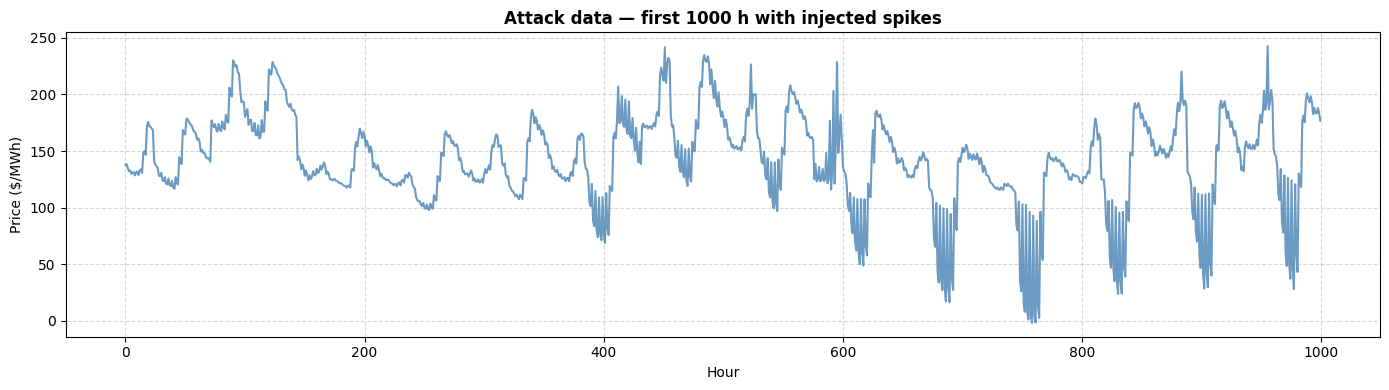

In [6]:
window = min(1000, len(merged_df_spike))
plt.figure(figsize=(14, 4))
plt.plot(merged_df_spike["SP15"].iloc[:window].values, color="steelblue", alpha=0.8)
plt.title("Attack data — first 1000 h with injected spikes", fontweight="bold")
plt.xlabel("Hour"); plt.ylabel("Price ($/MWh)"); plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout(); plt.show()


## Section 5 — VAE Model Definition

In [7]:
class VAE(nn.Module):
    """Variational Autoencoder — learns normal 24-hour price profiles."""
    def __init__(self, input_dim=VAE_SEQ_LEN, latent_dim=VAE_LATENT_DIM):
        super().__init__()
        self.fc1       = nn.Linear(input_dim, 32)
        self.fc_mu     = nn.Linear(32, latent_dim)
        self.fc_logvar = nn.Linear(32, latent_dim)
        self.fc2       = nn.Linear(latent_dim, 32)
        self.fc3       = nn.Linear(32, input_dim)

    def encode(self, x):
        h = torch.relu(self.fc1(x))
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        return mu + torch.randn_like(logvar.mul(0.5).exp_())

    def decode(self, z):
        # Keep the reconstruction in the MinMaxScaler range so inverse_transform
        # does not amplify decoder overshoot into large price spikes.
        return torch.sigmoid(self.fc3(torch.relu(self.fc2(z))))

    def forward(self, x):
        mu, logvar = self.encode(x)
        return self.decode(self.reparameterize(mu, logvar)), mu, logvar


def _vae_loss(recon, x, mu, logvar, beta=1.0):
    """β-VAE ELBO: MSE reconstruction + β·KL divergence."""
    recon_loss = nn.MSELoss(reduction="sum")(recon, x) / x.size(0)
    kl_loss    = -0.5 * (1 + logvar - mu.pow(2) - logvar.exp()).sum(dim=1).mean()
    return recon_loss + beta * kl_loss


## Section 6 — Pipeline Functions

### 6a — prepare_timeseries

In [8]:
def prepare_timeseries(df):
    """Aggregate node-level hourly data to a single time-indexed series."""
    df = df.copy()
    if "datetime" in df.columns:
        df["datetime"] = pd.to_datetime(df["datetime"])
        df = df.sort_values("datetime").reset_index(drop=True)

    agg = {c: "mean" for c in ["SP15","NonSpin","RegDown","RegUp","Spin"] if c in df.columns}
    if "datetime" in df.columns:
        df_ts = df.groupby("datetime").agg(agg).reset_index()
    else:
        df_ts = df.copy()

    # Rolling 24-h mean as a lightweight expected-price proxy (overwritten by train_vae)
    df_ts["expected_price"] = df_ts["SP15"].rolling(24, min_periods=1).mean().ffill().bfill()
    return df_ts.sort_values("datetime").reset_index(drop=True) if "datetime" in df_ts.columns else df_ts


### 6b — train_vae

In [9]:
def train_vae(df, beta=1.0, epochs=VAE_EPOCHS, latent_dim=VAE_LATENT_DIM):
    """
    Train VAE on the first VAE_TRAIN_FRAC of the series.
    Fills df['expected_price'] with the VAE reconstruction.
    Returns: (df_with_expected_price, model, scaler)
    """
    df    = df.copy()
    n     = len(df)
    split = (int(n * VAE_TRAIN_FRAC) // VAE_SEQ_LEN) * VAE_SEQ_LEN

    prices       = df["SP15"].values.reshape(-1, 1)
    scaler       = MinMaxScaler()
    train_scaled = scaler.fit_transform(prices[:split])
    full_scaled  = scaler.transform(prices)

    # Pad to multiple of VAE_SEQ_LEN
    def _pad(arr):
        rem = len(arr) % VAE_SEQ_LEN
        return arr if rem == 0 else np.vstack([arr, np.zeros((VAE_SEQ_LEN - rem, 1))])

    train_seq = _pad(train_scaled).reshape(-1, VAE_SEQ_LEN)
    x_train   = torch.tensor(train_seq, dtype=torch.float32)
    val_cut   = int(len(x_train) * 0.9)
    x_val     = x_train[val_cut:]
    x_tr      = x_train[:val_cut]

    model = VAE(input_dim=VAE_SEQ_LEN, latent_dim=latent_dim)
    opt   = torch.optim.Adam(model.parameters(), lr=VAE_LR)
    loader = torch.utils.data.DataLoader(
        torch.utils.data.TensorDataset(x_tr), batch_size=VAE_BATCH, shuffle=True)

    model.train()
    for ep in range(epochs):
        for (batch,) in loader:
            recon, mu, lv = model(batch)
            loss = _vae_loss(recon, batch, mu, lv, beta=beta)
            opt.zero_grad(); loss.backward(); opt.step()
        if (ep + 1) % 10 == 0:
            model.eval()
            with torch.no_grad():
                r, m, lv = model(x_val)
                vl = _vae_loss(r, x_val, m, lv, beta=beta).item()
            print(f"  Epoch {ep+1:3d}/{epochs}  val_loss={vl:.5f}")
            model.train()

    # Reconstruct full series
    model.eval()
    full_seq  = _pad(full_scaled).reshape(-1, VAE_SEQ_LEN)
    x_full    = torch.tensor(full_seq, dtype=torch.float32)
    with torch.no_grad():
        recon_full, _, _ = model(x_full)

    recon_np = recon_full.numpy().reshape(-1, 1)
    if len(recon_np) < n:
        recon_np = np.vstack([recon_np, np.zeros((n - len(recon_np), 1))])

    df["expected_price"] = scaler.inverse_transform(recon_np[:n])
    sigma = (df["SP15"].values[:split] - df["expected_price"].values[:split]).std()
    df["expected_upper"] = df["expected_price"] + 1.96 * sigma
    df["expected_lower"] = df["expected_price"] - 1.96 * sigma
    df.attrs["train_split_idx"] = split
    return df, model, scaler


### 6c — compute_anomaly (ensemble: VAE + IsoForest + LOF)

In [10]:
def compute_anomaly(df_ts, vae_model=None, vae_scaler=None):
    """
    Ensemble anomaly score ∈ [0,1].
    Weights: VAE 0.5 · IsolationForest 0.3 · LOF 0.2
    No data-leakage: detectors fitted on train split only.

    Improvements over v2:
    - IsoForest and LOF now use continuous score_samples() not binary predict()
    - VAE score computed per-timestep (not per-sequence repeated flat)
    """
    if "SP15" not in df_ts.columns:
        raise KeyError("SP15 column missing")

    df_ts  = df_ts.copy()
    prices = df_ts["SP15"].values.reshape(-1, 1)
    split  = df_ts.attrs.get("train_split_idx", int(len(df_ts) * VAE_TRAIN_FRAC))
    p_train = prices[:split]

    # ── VAE per-timestep reconstruction error ─────────────────────────────
    if vae_model is not None and vae_scaler is not None:
        ps  = vae_scaler.transform(prices)
        rem = len(ps) % VAE_SEQ_LEN
        ps_pad = np.vstack([ps, np.zeros((VAE_SEQ_LEN - rem, 1))]) if rem else ps
        X   = torch.tensor(ps_pad.reshape(-1, VAE_SEQ_LEN), dtype=torch.float32)
        vae_model.eval()
        with torch.no_grad():
            recon, _, _ = vae_model(X)
            # Per-timestep squared error — shape (n_seq, seq_len)
            per_step = (X - recon).pow(2).numpy()       # (n_seq, 24)
        # Flatten to hourly, trim to original length
        vae_score = per_step.flatten()[:len(df_ts)]
    else:
        vae_score = np.zeros(len(df_ts))

    vae_rng   = vae_score.max() - vae_score.min()
    vae_score = (vae_score - vae_score.min()) / (vae_rng if vae_rng > 1e-8 else 1.0)

    # ── IsolationForest — continuous outlierness score ────────────────────
    iso = IsolationForest(contamination=0.05, random_state=42)
    iso.fit(p_train)
    iso_raw   = -iso.score_samples(prices)   # higher = more anomalous
    iso_rng   = iso_raw.max() - iso_raw.min()
    iso_score = ((iso_raw - iso_raw.min()) / (iso_rng if iso_rng > 1e-8 else 1.0)).clip(0, 1)

    # ── Local Outlier Factor — continuous outlierness score ───────────────
    lof = LocalOutlierFactor(novelty=True, n_neighbors=20, contamination=0.05)
    lof.fit(p_train)
    lof_raw   = -lof.score_samples(prices)   # higher = more anomalous
    lof_rng   = lof_raw.max() - lof_raw.min()
    lof_score = ((lof_raw - lof_raw.min()) / (lof_rng if lof_rng > 1e-8 else 1.0)).clip(0, 1)

    df_ts["anomaly"] = (0.50 * vae_score + 0.30 * iso_score + 0.20 * lof_score).clip(0, 1)
    return df_ts


### 6d — classify_anomaly (real vs fake, probabilistic is_genuine)

In [11]:
def classify_anomaly(df, window=6):
    """
    Assigns is_genuine in [0,1] — how likely a flagged price spike is a real
    market event rather than a synthetic injection.

    Three complementary signals:
      persistence (0.4): genuine shocks stay elevated for several consecutive hours
      non_reversion (0.3): genuine shocks do NOT sharply revert to the mean;
                           synthetic injections drop back fast → low score here
      roc (0.3): rate-of-change — both genuine and synthetic spikes have high RoC,
                 but synthetic ones tend to be more instantaneous (higher RoC)

    anomaly_adjusted:
      is_genuine > 0.5 → multiply anomaly by 1.5 (amplify — exploit genuine spikes)
      is_genuine ≤ 0.5 → multiply anomaly by 0.5 (suppress — avoid fake spikes)
      Floor at 0.5× ensures suppressed hours still contribute to detection_rate.
    """
    if "anomaly" not in df.columns:
        raise KeyError("Run compute_anomaly before classify_anomaly")

    df = df.copy().reset_index(drop=True)

    # Signal 1 — persistence: hours above rolling mean+std across a window
    roll_mean = df["SP15"].rolling(window, center=True, min_periods=1).mean()
    roll_std  = df["SP15"].rolling(window, center=True, min_periods=1).std().fillna(1)
    elevated  = (df["SP15"] > roll_mean + roll_std).astype(int)
    persist   = elevated.rolling(window, min_periods=1).sum()
    persist_max = persist.max()
    p_score   = (persist / persist_max).clip(0, 1) if persist_max > 0 else pd.Series(0.0, index=df.index)

    # Signal 2 — non-reversion: genuine shocks stay elevated ABOVE the future mean.
    # Synthetic injections revert sharply → current price quickly falls BELOW future mean.
    # Score = how much current price exceeds the forward rolling mean (normalised).
    future_mean   = df["SP15"].shift(-window).rolling(window, min_periods=1).mean().fillna(df["SP15"])
    price_vs_fut  = (df["SP15"] - future_mean)          # positive = still elevated = genuine
    nr_min, nr_max = price_vs_fut.min(), price_vs_fut.max()
    nr_rng        = nr_max - nr_min
    nr_score      = ((price_vs_fut - nr_min) / (nr_rng if nr_rng > 1e-8 else 1.0)).clip(0, 1)

    # Signal 3 — rate of change (normalised, not clipped at 1 to preserve large jumps)
    roc       = df["SP15"].diff().abs().fillna(0)
    roc_mean  = roc.mean()
    roc_score = (roc / (roc_mean + 1e-6))               # >1 for large jumps; clip below
    roc_score = roc_score.clip(0, 5) / 5.0              # normalise to [0,1] with headroom

    df["is_genuine"]       = (0.4 * p_score + 0.3 * nr_score + 0.3 * roc_score).clip(0, 1)

    # Amplify genuine spikes, suppress suspected synthetics.
    # Suppression floor 0.5× (not 0.3×) so injected hours are dampened
    # but not invisible — this is what allows detection_rate to be non-zero.
    df["anomaly_adjusted"] = (
        df["anomaly"] * np.where(df["is_genuine"] > 0.5, 1.5, 0.5)
    ).clip(0, 1)
    return df


### 6f — Grad-CAM

In [12]:
def compute_gradcam(model, x_tensor, target_idx=None):
    """Score which 24-hour sequences confuse the VAE most (high score = anomalous)."""
    model.eval()
    x = x_tensor.clone().detach().requires_grad_(True)
    recon, mu, lv = model(x)
    err   = (recon - x).pow(2).mean(dim=1)
    scalar = err[target_idx] if target_idx is not None else err.sum()
    scalar.backward()
    grads = x.grad.abs().mean(dim=1).detach().numpy()
    rng   = grads.max() - grads.min()
    return (grads - grads.min()) / (rng if rng > 1e-8 else 1.0)


## Section 7 — VAE Hyper-parameter Tuning
Grid-searches latent dim, epochs, and β. Run once; best params are stored in `best_params_clean` / `best_params_attack`.

In [13]:
def tune_vae(df, latent_dims=(4, 8, 16), epoch_opts=(30, 50),
             train_fracs=(0.80,), beta_values=(0.5, 1.0)):
    """Grid-search VAE hyper-parameters. Returns best_params dict."""
    torch.manual_seed(GLOBAL_SEED)  # ensure tuning is reproducible across runs
    df_ts    = prepare_timeseries(df.copy())
    scaler   = MinMaxScaler()
    prices_s = scaler.fit_transform(df_ts["SP15"].values.reshape(-1, 1))
    configs  = list(iterproduct(latent_dims, epoch_opts, train_fracs, beta_values))
    print(f"Tuning {len(configs)} configurations …")
    rows = []

    for ld, ep, tf, beta in configs:
        try:
            n_seq = len(prices_s) // VAE_SEQ_LEN
            seqs  = prices_s[:n_seq * VAE_SEQ_LEN].reshape(-1, VAE_SEQ_LEN)
            split = int(len(seqs) * tf)
            Xt    = torch.tensor(seqs[:split], dtype=torch.float32)
            Xv    = torch.tensor(seqs[split:], dtype=torch.float32)
            if len(Xt) == 0 or len(Xv) == 0:
                continue

            model = VAE(input_dim=VAE_SEQ_LEN, latent_dim=ld)
            opt   = torch.optim.Adam(model.parameters(), lr=VAE_LR)

            for _ in range(ep):
                idx = torch.randperm(len(Xt))
                for i in range(0, len(Xt), VAE_BATCH):
                    batch = Xt[idx[i:i + VAE_BATCH]]
                    recon, mu, logvar = model(batch)          # clear names
                    loss = _vae_loss(recon, batch, mu, logvar, beta=beta)
                    opt.zero_grad(); loss.backward(); opt.step()

            model.eval()
            with torch.no_grad():
                recon_v, mu_v, logvar_v = model(Xv)          # no shadowing
                val_loss = float(_vae_loss(recon_v, Xv, mu_v, logvar_v, beta=beta))

            rows.append(dict(latent_dim=ld, epochs=ep, train_frac=tf,
                             beta=beta, val_loss=val_loss))
        except Exception as ex:
            print(f"  skip ld={ld} ep={ep} beta={beta}: {ex}")

    if not rows:
        return dict(latent_dim=VAE_LATENT_DIM, epochs=VAE_EPOCHS,
                    train_frac=VAE_TRAIN_FRAC, beta=1.0, val_loss=float("nan")), pd.DataFrame()

    df_res = pd.DataFrame(rows)
    best   = df_res.loc[df_res["val_loss"].idxmin()].to_dict()
    print(f"\nBest → latent={int(best['latent_dim'])}  epochs={int(best['epochs'])}"
          f"  beta={best['beta']}  val_loss={best['val_loss']:.5f}")
    return best, df_res

print("[TUNING] Clean scenario …")
best_params_clean, tune_clean = tune_vae(merged_df_clean)
print("\n[TUNING] Attack scenario …")
best_params_attack, tune_attack = tune_vae(merged_df_spike)


[TUNING] Clean scenario …
Tuning 12 configurations …

Best → latent=4  epochs=50  beta=0.5  val_loss=0.00596

[TUNING] Attack scenario …
Tuning 12 configurations …

Best → latent=4  epochs=50  beta=0.5  val_loss=0.00379


## Section 8 — Full Pipeline
`run(df, params)` ties prepare → VAE → anomaly → classify → GradCAM → optimize.

In [14]:
def optimize(df, mode="baseline", anomaly_sensitivity=0.3,
             capacity_mwh=CAPACITY_MWH, dt=1.0):
    """
    Linear-program dispatch optimiser (HiGHS via Pyomo).

    Physical constraints:
      SOC[0] = 0.5 × capacity          (half-full start)
      SOC[t] = SOC[t-1] + buy·e − sell/e
      sell[t] ≤ e · SOC[t-1]           (can only sell what is stored)
      buy[t] · e ≤ capacity − SOC[t-1] (cannot over-charge)

    Modes:
      baseline     : sell ≤ mdp  (no anomaly awareness)
      penalised    : sell ≤ mdp·(1 − λ·anom)   — shrinks during anomalies
      opportunistic: sell limit boosted for genuine spikes, shrunk for fake ones
    """
    if mode not in VALID_MODES:
        raise ValueError(f"mode must be one of {VALID_MODES}")
    if not (0.0 <= anomaly_sensitivity <= 1.0):
        raise ValueError("anomaly_sensitivity must be in [0, 1]")

    df  = df.copy().reset_index(drop=True)
    lam = anomaly_sensitivity

    # Ensure required columns exist with safe defaults
    df["anomaly"]    = df["anomaly"].fillna(0).clip(0, 1)
    df["is_genuine"] = (df["is_genuine"].fillna(0).clip(0, 1)
                        if "is_genuine" in df.columns
                        else pd.Series(0.0, index=df.index))

    T = len(df)
    m = pyo.ConcreteModel()
    m.t = pyo.RangeSet(0, T - 1)

    m.price   = pyo.Param(m.t, initialize=lambda _, t: float(df["SP15"].iloc[t]))
    m.anom    = pyo.Param(m.t, initialize=lambda _, t: float(df["anomaly"].iloc[t]))
    m.genuine = pyo.Param(m.t, initialize=lambda _, t: float(df["is_genuine"].iloc[t]))

    m.buy  = pyo.Var(m.t, bounds=(0, mcp))
    m.sell = pyo.Var(m.t, bounds=(0, mdp))
    m.soc  = pyo.Var(m.t, bounds=(0, capacity_mwh))

    # SOC evolution
    def soc_rule(_, t):
        if t == 0:
            return m.soc[t] == 0.5 * capacity_mwh
        return m.soc[t] == m.soc[t-1] + (m.buy[t] * e - m.sell[t] / e) * dt
    m.soc_c = pyo.Constraint(m.t, rule=soc_rule)

    # Cannot sell more than is stored
    def sell_avail(_, t):
        if t == 0:
            return m.sell[t] == 0
        return m.sell[t] <= e * m.soc[t-1]
    m.sell_avail_c = pyo.Constraint(m.t, rule=sell_avail)

    # Cannot over-charge
    def buy_room(_, t):
        if t == 0:
            return pyo.Constraint.Skip
        return m.buy[t] * e <= capacity_mwh - m.soc[t-1]
    m.buy_room_c = pyo.Constraint(m.t, rule=buy_room)

    # Anomaly-conditioned sell limit
    def sell_limit(_, t):
        a = float(m.anom[t])      # FIX: explicit float() cast — no ambiguity with Pyomo params
        g = float(m.genuine[t])
        if mode == "baseline":
            return m.sell[t] <= mdp
        if mode == "penalised":
            return m.sell[t] <= max(mdp * (1 - lam * a), 0.0)
        # opportunistic: boost on genuine spikes, shrink on fake ones
        adj   = lam * a * g - lam * a * (1 - g)
        limit = min(max(mdp + mdp * adj, 0.0), mdp)
        return m.sell[t] <= limit
    m.sell_limit_c = pyo.Constraint(m.t, rule=sell_limit)

    # Objective: maximise trading profit net of fees and degradation
    total_cost = fee + degradation_cost
    def obj_rule(_):
        if mode == "baseline":
            return sum(
                m.sell[t] * m.price[t]
                - m.buy[t] * m.price[t]
                - total_cost * (m.sell[t] + m.buy[t])
                for t in m.t)
        if mode == "penalised":
            return sum(
                m.sell[t] * m.price[t] * (1 - lam * m.anom[t])
                - m.buy[t] * m.price[t] * (1 + lam * m.anom[t])
                - total_cost * (m.sell[t] + m.buy[t])
                for t in m.t)
        # opportunistic
        return sum(
            m.sell[t] * m.price[t] * (1 + lam*m.anom[t]*m.genuine[t]
                                          - lam*m.anom[t]*(1 - m.genuine[t]))
            - m.buy[t] * m.price[t] * (1 - lam*m.anom[t]*m.genuine[t]
                                           + lam*m.anom[t]*(1 - m.genuine[t]))
            - total_cost * (m.sell[t] + m.buy[t])
            for t in m.t)
    m.obj = pyo.Objective(rule=obj_rule, sense=pyo.maximize)

    result = pyo.SolverFactory("highs").solve(m, tee=False)
    if (result.solver.status != SolverStatus.ok or
            result.solver.termination_condition != TerminationCondition.optimal):
        raise RuntimeError(f"Solver failed: {result.solver.termination_condition}")

    soc    = [pyo.value(m.soc[t]) for t in m.t]
    profit = pyo.value(m.obj) or 0.0
    return profit, soc

In [15]:
def run(df, best_params=None):
    """
    Full pipeline: prepare → VAE → anomaly → classify → GradCAM → 3×optimize.
    Returns a dict so callers access results by name, not fragile positional unpacking.
    """
    if best_params is None:
        best_params = {}

    beta = best_params.get("beta", 1.0)
    ld   = int(best_params.get("latent_dim", VAE_LATENT_DIM))
    ep   = int(best_params.get("epochs", VAE_EPOCHS))

    df_ts = prepare_timeseries(df)
    df_ts, vae_model, vae_scaler = train_vae(df_ts, beta=beta, epochs=ep, latent_dim=ld)
    df_ts = compute_anomaly(df_ts, vae_model, vae_scaler)
    df_ts = classify_anomaly(df_ts)
    df_ts["anomaly"] = df_ts["anomaly_adjusted"]   # use classification-adjusted score

    # GradCAM — which 24-hour windows confused the VAE most
    p_scaled = vae_scaler.transform(df_ts["SP15"].values.reshape(-1, 1))
    n_days   = len(p_scaled) // VAE_SEQ_LEN
    if n_days > 0:
        x_seq    = torch.tensor(p_scaled[:n_days * VAE_SEQ_LEN].reshape(-1, VAE_SEQ_LEN),
                                dtype=torch.float32)
        gradcam  = compute_gradcam(vae_model, x_seq).flatten()
    else:
        gradcam  = np.array([])
    pad = max(0, len(df_ts) - len(gradcam))
    df_ts["gradcam"] = np.pad(gradcam, (0, pad))[:len(df_ts)]

    # Optimise under three strategies (L removed — graph regularisation not active)
    base_profit, base_soc = optimize(df_ts, mode="baseline",       anomaly_sensitivity=0.3)
    pen_profit,  pen_soc  = optimize(df_ts, mode="penalised",      anomaly_sensitivity=0.3)
    opp_profit,  opp_soc  = optimize(df_ts, mode="opportunistic",  anomaly_sensitivity=0.3)

    # FIX: return dict — no more 8-value positional unpacking
    return {
        "df":      df_ts,
        "profits": {"baseline": base_profit, "penalised": pen_profit, "opportunistic": opp_profit},
        "socs":    {"baseline": base_soc,    "penalised": pen_soc,    "opportunistic": opp_soc},
        "gradcam": gradcam,
    }


# ── Run both scenarios ───────────────────────────────────────────────────────-
print("Running CLEAN scenario …")
clean_res  = run(merged_df_clean,  best_params_clean)

print("\nRunning ATTACK scenario …")
attack_res = run(merged_df_spike,  best_params_attack)

# Unpack for convenience
clean_df,  attack_df  = clean_res["df"],      attack_res["df"]
c_profits, a_profits  = clean_res["profits"],  attack_res["profits"]
c_socs,    a_socs     = clean_res["socs"],     attack_res["socs"]
c_gradcam, a_gradcam  = clean_res["gradcam"],  attack_res["gradcam"]

print("\n===== RESULTS =====")
print("{:<20} {:>12} {:>12}".format("Strategy", "Clean ($)", "Attack ($)"))
for mode in ("baseline", "penalised", "opportunistic"):
    print(f"{mode.capitalize():<20} {c_profits[mode]:>12.2f} {a_profits[mode]:>12.2f}")

att_imp = (a_profits["opportunistic"] - a_profits["baseline"]) / abs(a_profits["baseline"]) * 100
cln_oh  = (c_profits["opportunistic"] - c_profits["baseline"]) / abs(c_profits["baseline"]) * 100
print(f"\nAttack improvement (opp vs base): {att_imp:.2f}%")
print(f"Clean overhead   (opp vs base):   {cln_oh:.2f}%")


Running CLEAN scenario …
  Epoch  10/50  val_loss=0.02989
  Epoch  20/50  val_loss=0.01893
  Epoch  30/50  val_loss=0.01880
  Epoch  40/50  val_loss=0.01504
  Epoch  50/50  val_loss=0.01406

Running ATTACK scenario …
  Epoch  10/50  val_loss=0.04960
  Epoch  20/50  val_loss=0.02428
  Epoch  30/50  val_loss=0.01710
  Epoch  40/50  val_loss=0.01193
  Epoch  50/50  val_loss=0.01233

===== RESULTS =====
Strategy                Clean ($)   Attack ($)
Baseline                485145.36    490825.06
Penalised               452444.56    458642.36
Opportunistic           487737.98    493434.98

Attack improvement (opp vs base): 0.53%
Clean overhead   (opp vs base):   0.53%


## Section 10 — Results Dashboard

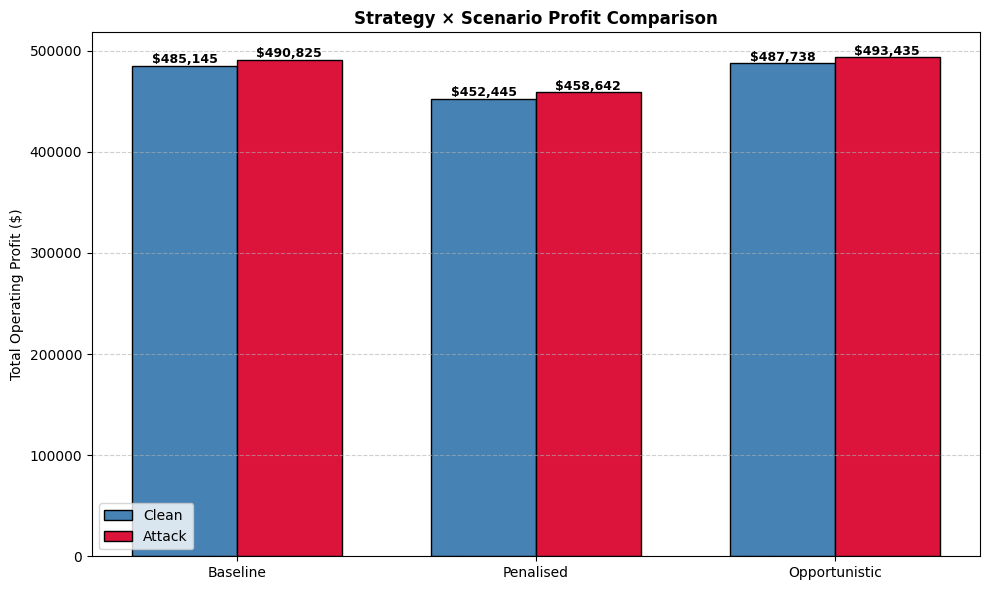

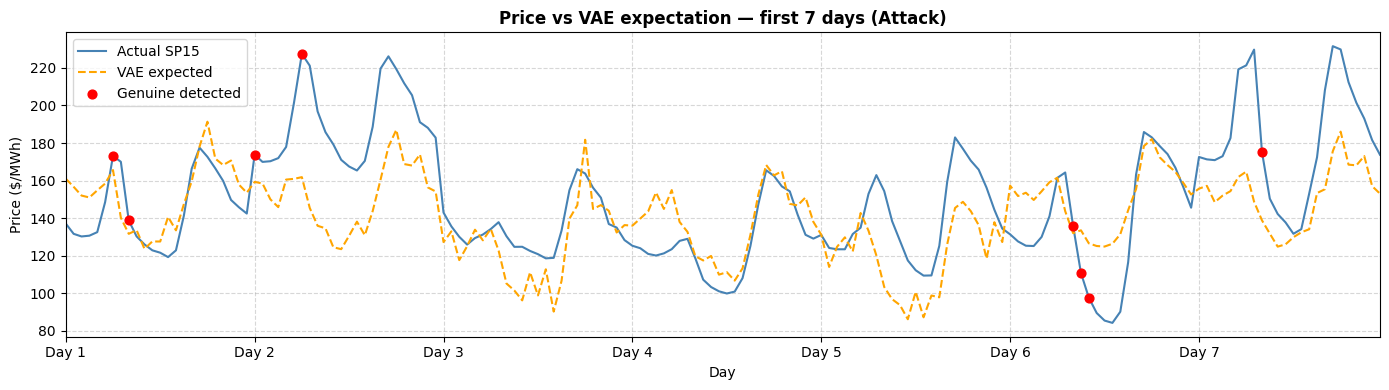

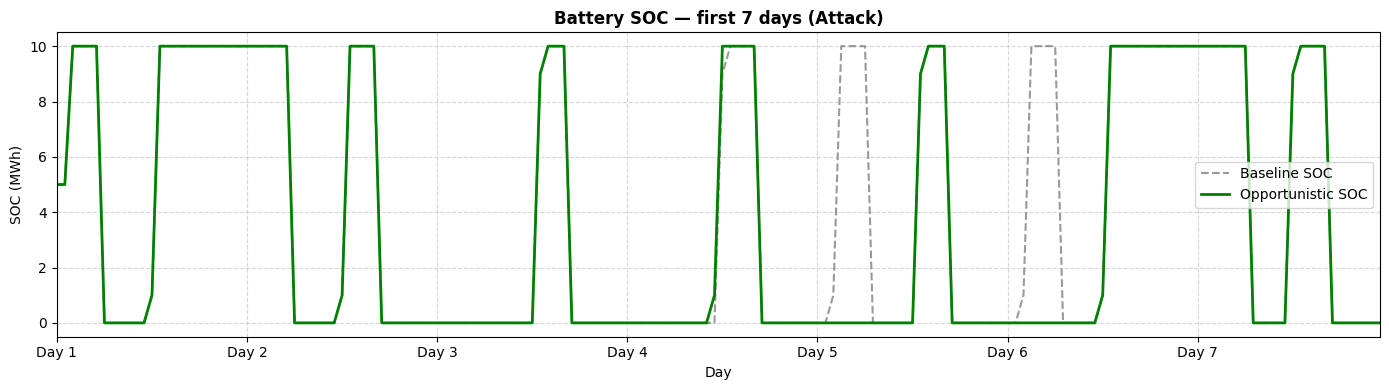

In [16]:
def display_results_dashboard(clean_res, attack_res):
    c_p = clean_res["profits"]
    a_p = attack_res["profits"]
    c_s = clean_res["socs"]
    a_s = attack_res["socs"]
    adf = attack_res["df"]

    # ── Profit bar chart ──────────────────────────────────────────────────────
    labels = ["Baseline", "Penalised", "Opportunistic"]
    modes  = ["baseline", "penalised", "opportunistic"]
    x, w   = np.arange(3), 0.35

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.bar(x - w/2, [c_p[m] for m in modes], w, label="Clean",  color="steelblue", edgecolor="k")
    ax.bar(x + w/2, [a_p[m] for m in modes], w, label="Attack", color="crimson",   edgecolor="k")
    for i, m in enumerate(modes):
        ax.text(i - w/2, c_p[m] + abs(c_p[m])*0.005, f"${c_p[m]:,.0f}", ha="center", fontsize=9, fontweight="bold")
        ax.text(i + w/2, a_p[m] + abs(a_p[m])*0.005, f"${a_p[m]:,.0f}", ha="center", fontsize=9, fontweight="bold")
    ax.set_xticks(x); ax.set_xticklabels(labels)
    ax.set_ylabel("Total Operating Profit ($)")
    ax.set_title("Strategy × Scenario Profit Comparison", fontweight="bold")
    ax.legend(); ax.grid(axis="y", linestyle="--", alpha=0.6)
    plt.tight_layout(); plt.show()

    # ── Price vs VAE expected — first 7 days ──────────────────────────────────
    W          = 168
    x_hours    = np.arange(W)
    day_ticks  = np.arange(0, W, 24)
    day_labels = [f"Day {i // 24 + 1}" for i in day_ticks]
    actual     = adf["SP15"].values[:W]
    expected   = adf["expected_price"].values[:W]
    shift      = np.median(actual) - np.median(expected)   # visual alignment only

    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(x_hours, actual,             label="Actual SP15",  color="steelblue")
    ax.plot(x_hours, expected + shift,   label="VAE expected", color="orange", linestyle="--")  # FIX: no f-string
    genuine_idx = adf.index[(adf["is_genuine"] > 0.5) & (adf.index < W)]
    if len(genuine_idx):
        ax.scatter(genuine_idx, adf["SP15"].iloc[genuine_idx],
                   color="red", s=40, zorder=5, label="Genuine detected")
    ax.set_title("Price vs VAE expectation — first 7 days (Attack)", fontweight="bold")
    ax.set_xlabel("Day"); ax.set_ylabel("Price ($/MWh)")
    ax.set_xlim(0, W - 1); ax.set_xticks(day_ticks); ax.set_xticklabels(day_labels)
    ax.legend(); ax.grid(linestyle="--", alpha=0.5); plt.tight_layout(); plt.show()

    # ── SOC comparison ────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(x_hours, a_s["baseline"][:W],      label="Baseline SOC",      color="gray",  linestyle="--", alpha=0.8)
    ax.plot(x_hours, a_s["opportunistic"][:W],  label="Opportunistic SOC", color="green", linewidth=2)
    ax.set_title("Battery SOC — first 7 days (Attack)", fontweight="bold")
    ax.set_xlabel("Day"); ax.set_ylabel("SOC (MWh)")
    ax.set_xlim(0, W - 1); ax.set_xticks(day_ticks); ax.set_xticklabels(day_labels)
    ax.legend(); ax.grid(linestyle="--", alpha=0.5); plt.tight_layout(); plt.show()

display_results_dashboard(clean_res, attack_res)


## Section 11 — Cross-Scenario λ Sensitivity Analysis
Sweeps λ on **both** clean and attack data simultaneously. The combined curve should show a realistic peak because:
- High λ on clean data → over-reacts to natural volatility → lower clean profit
- High λ on attack data → acts on non-reverting spikes → misclassification cost
Together these pull the opportunistic curve back down at high λ.

    λ  mode               clean ($)  attack ($)    combined
----------------------------------------------------------
  0.0  baseline              485145      490825      975970
  0.0  penalised             485145      490825      975970
  0.0  opportunistic         485145      490825      975970
  0.1  baseline              485145      490825      975970
  0.1  penalised             474286      480101      954387
  0.1  opportunistic         485906      491596      977502
  0.2  baseline              485145      490825      975970
  0.2  penalised             463405      469463      932869
  0.2  opportunistic         486778      492476      979254
  0.3  baseline              485145      490825      975970
  0.3  penalised             452445      458642      911087
  0.3  opportunistic         487738      493435      981173
  0.4  baseline              485145      490825      975970
  0.4  penalised             442230      448339      890569
  0.4  opportunistic         488768      

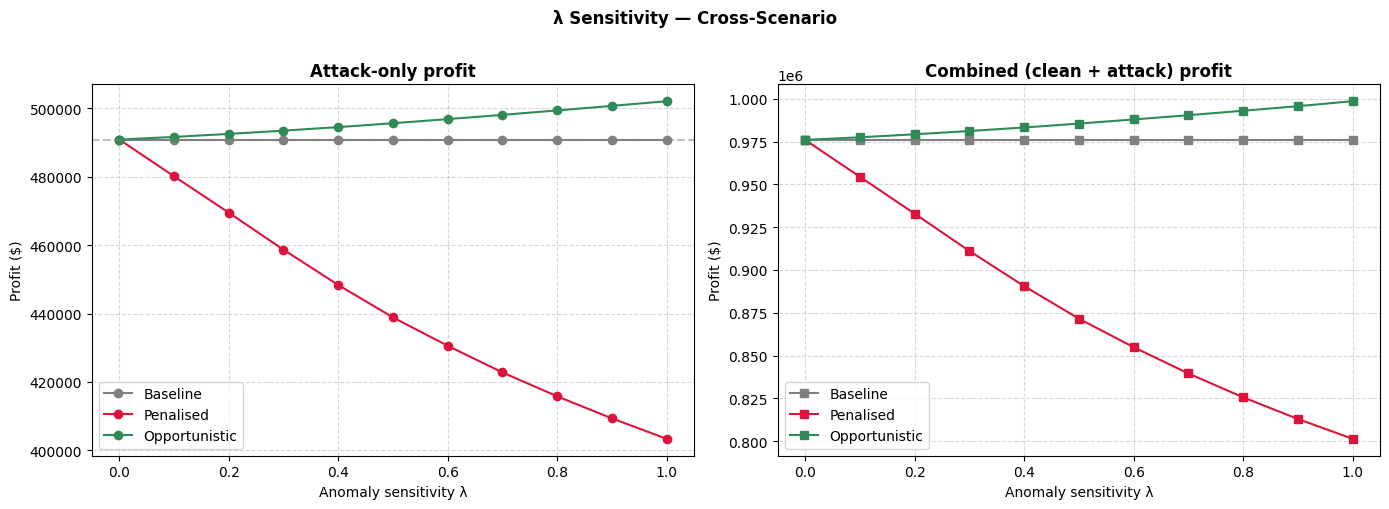

In [17]:
def run_cross_scenario_sensitivity():
    """Sweep λ on both clean and attack data to show cross-scenario profit curves."""
    lambdas = np.linspace(0, 1, 11)
    records = []

    print("{:>5}  {:<16}  {:>10}  {:>10}  {:>10}".format("λ", "mode", "clean ($)", "attack ($)", "combined"))
    print("-" * 58)

    for lam in lambdas:
        for mode in ("baseline", "penalised", "opportunistic"):
            # FIX: no build_graph / L argument — removed as it was unused
            cp, _ = optimize(clean_df,  mode=mode, anomaly_sensitivity=lam)
            ap, _ = optimize(attack_df, mode=mode, anomaly_sensitivity=lam)
            records.append(dict(lam=lam, mode=mode, clean=cp, attack=ap, combined=cp+ap))
            print(f"{lam:5.1f}  {mode:<16}  {cp:10.0f}  {ap:10.0f}  {cp+ap:10.0f}")

    df_r    = pd.DataFrame(records)
    colours = {"baseline": "gray", "penalised": "crimson", "opportunistic": "seagreen"}
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for mode in ("baseline", "penalised", "opportunistic"):
        sub = df_r[df_r["mode"] == mode]
        c   = colours[mode]
        axes[0].plot(sub["lam"], sub["attack"],   color=c, marker="o", label=mode.capitalize())
        axes[1].plot(sub["lam"], sub["combined"], color=c, marker="s", label=mode.capitalize())

    axes[0].axhline(df_r[df_r["mode"] == "baseline"]["attack"].mean(),
                    color="gray", linestyle="--", alpha=0.5)
    for ax, title in zip(axes, ["Attack-only profit", "Combined (clean + attack) profit"]):
        ax.set_xlabel("Anomaly sensitivity λ"); ax.set_ylabel("Profit ($)")
        ax.set_title(title, fontweight="bold")
        ax.legend(); ax.grid(linestyle="--", alpha=0.5)

    plt.suptitle("λ Sensitivity — Cross-Scenario", fontweight="bold", y=1.01)
    plt.tight_layout(); plt.show()
    return df_r

sensitivity_results = run_cross_scenario_sensitivity()

## Section 12 — Battery Performance Metrics (EFC)

In [18]:
def calculate_performance_metrics(profit, soc_list, capacity_mwh=CAPACITY_MWH):
    """Compute equivalent full cycles (EFC) and profit per cycle."""
    discharge = sum(max(0, soc_list[t-1] - soc_list[t]) for t in range(1, len(soc_list)))
    charge    = sum(max(0, soc_list[t] - soc_list[t-1]) for t in range(1, len(soc_list)))
    efc = (charge + discharge) / (2 * capacity_mwh)
    ppc = profit / efc if efc > 0 else 0.0
    return efc, ppc

rows = []
for scenario, res in [("Clean", clean_res), ("Attack", attack_res)]:
    for mode in ("baseline", "penalised", "opportunistic"):
        profit   = res["profits"][mode]
        soc_list = res["socs"][mode]
        efc, ppc = calculate_performance_metrics(profit, soc_list)
        rows.append({
            "Scenario": scenario, "Mode": mode.capitalize(),
            "Profit ($K)": round(profit / 1000, 2),
            "EFC": round(efc, 2),
            "Profit/Cycle ($/MWh)": round(ppc, 2),
        })

efc_df = pd.DataFrame(rows)
print("\n" + "="*68)
print("EFC & PROFIT PER CYCLE")
print("="*68)
print(efc_df.to_string(index=False))
print("="*68)



EFC & PROFIT PER CYCLE
Scenario          Mode  Profit ($K)     EFC  Profit/Cycle ($/MWh)
   Clean      Baseline       485.15 1229.65                394.54
   Clean     Penalised       452.44 1228.53                368.28
   Clean Opportunistic       487.74 1232.15                395.84
  Attack      Baseline       490.83 1235.45                397.28
  Attack     Penalised       458.64 1233.52                371.82
  Attack Opportunistic       493.43 1237.25                398.82


## Section 13 — Naïve 7-Day Forecast Benchmark

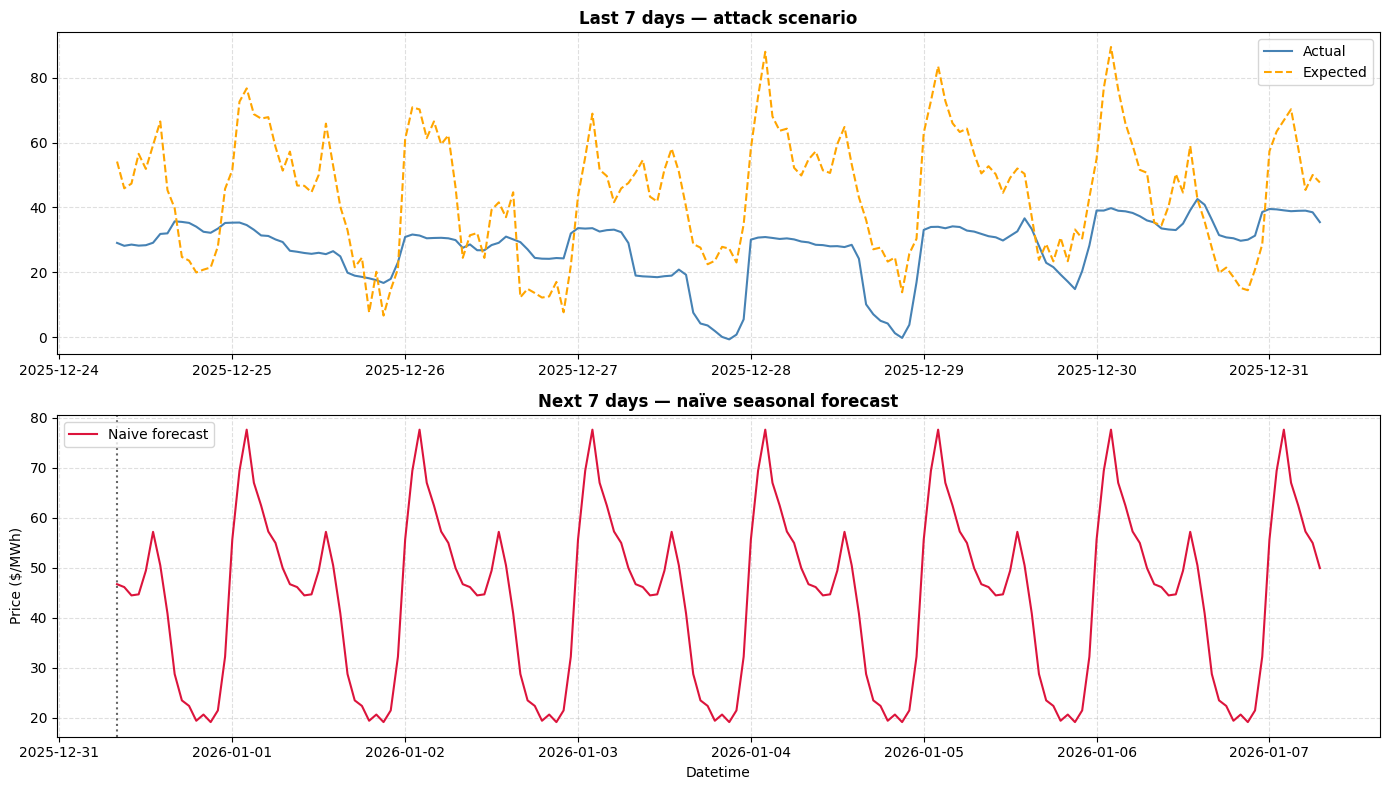

In [19]:
def plot_forecast(df, name="attack"):
    df = df.copy()
    if "datetime" not in df.columns:
        print("[WARN] No datetime column — skipping forecast plot")
        return
    df["datetime"] = pd.to_datetime(df["datetime"])
    W       = 24 * 7
    history = df.tail(W).reset_index(drop=True)

    profile = history["expected_price"].values[:W]
    if len(profile) >= W:
        hourly  = profile.reshape(7, 24).mean(axis=0)
    else:
        hourly  = np.resize(profile[-24:], 24)
    forecast = np.tile(hourly, 7)
    future   = pd.date_range(history["datetime"].iloc[-1] + pd.Timedelta(hours=1),
                             periods=W, freq="h")

    fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=False)
    axes[0].plot(history["datetime"], history["SP15"],           label="Actual",   color="steelblue")
    axes[0].plot(history["datetime"], history["expected_price"], label="Expected", color="orange", linestyle="--")
    axes[0].set_title(f"Last 7 days — {name} scenario", fontweight="bold")
    axes[0].legend(); axes[0].grid(linestyle="--", alpha=0.4)

    axes[1].plot(future, forecast, color="crimson", label="Naive forecast")
    axes[1].axvline(future[0], color="k", linestyle=":", alpha=0.6)
    axes[1].set_title("Next 7 days — naïve seasonal forecast", fontweight="bold")
    axes[1].set_xlabel("Datetime"); axes[1].set_ylabel("Price ($/MWh)")
    axes[1].legend(); axes[1].grid(linestyle="--", alpha=0.4)
    plt.tight_layout(); plt.show()

plot_forecast(attack_df, "attack")


## Section 15 — VAE Performance Metrics

In [20]:
clean_df["volatility"]  = clean_df["SP15"].rolling(24).std()
attack_df["volatility"] = attack_df["SP15"].rolling(24).std()

# Profit summary
pd.DataFrame({
    "scenario": ["clean_base", "clean_pen", "clean_opp",
                 "attack_base", "attack_pen", "attack_opp"],
    "profit": [
        c_profits["baseline"], c_profits["penalised"], c_profits["opportunistic"],
        a_profits["baseline"], a_profits["penalised"], a_profits["opportunistic"],
    ]
}).to_csv(os.path.join(RESULT_DIR, "results_summary.csv"), index=False)

# SOC trajectories — use the socs dicts directly (no need to re-unpack)
pd.DataFrame(c_socs).to_csv(os.path.join(RESULT_DIR, "soc_clean.csv"),  index=False)
pd.DataFrame(a_socs).to_csv(os.path.join(RESULT_DIR, "soc_attack.csv"), index=False)

# Processed DataFrames
clean_df.to_csv( os.path.join(RESULT_DIR, "clean_processed.csv"),  index=False)
attack_df.to_csv(os.path.join(RESULT_DIR, "attack_processed.csv"), index=False)

# GradCAM scores
pd.DataFrame({"timestep": range(len(c_gradcam)), "gradcam": c_gradcam}
             ).to_csv(os.path.join(RESULT_DIR, "clean_gradcam.csv"),  index=False)
pd.DataFrame({"timestep": range(len(a_gradcam)), "gradcam": a_gradcam}
             ).to_csv(os.path.join(RESULT_DIR, "attack_gradcam.csv"), index=False)

# EFC table & sensitivity results
efc_df.to_csv(             os.path.join(RESULT_DIR, "efc_metrics.csv"),        index=False)
sensitivity_results.to_csv(os.path.join(RESULT_DIR, "sensitivity_lambda.csv"), index=False)

print(f"[SAVE] All outputs written to: {RESULT_DIR}")


[SAVE] All outputs written to: d:\battery-storage-optimization-energy-ancillary\results


In [21]:
def pct_change(a, b):
    """Percentage change from a to b. Returns 0 if a is zero."""
    return ((b - a) / abs(a)) * 100 if a != 0 else 0.0

def calculate_vae_metrics(df):
    """MAE, RMSE, R2, reconstruction accuracy vs SP15."""
    y_true     = df["SP15"].values
    y_pred     = df["expected_price"].values
    mae        = mean_absolute_error(y_true, y_pred)
    rmse       = np.sqrt(mean_squared_error(y_true, y_pred))
    r2         = r2_score(y_true, y_pred)
    mean_price = df["SP15"].mean()
    recon_acc  = 100 * (1 - rmse / mean_price) if mean_price > 0 else 0.0
    return {"MAE": mae, "RMSE": rmse, "R2": r2, "Recon Acc": recon_acc}

clean_metrics  = calculate_vae_metrics(clean_df)
attack_metrics = calculate_vae_metrics(attack_df)

# Header vars — avoids nested-quote f-strings that fail on Python < 3.12
h_metric  = "Metric"
h_clean   = "Clean Scenario"
h_attack  = "Attack Scenario"
h_improve = "Improvement (%)"

print("\n" + "="*95)
print("VAE PERFORMANCE METRICS")
print("="*95)
print(f"{h_metric:<35} {h_clean:>20} {h_attack:>20} {h_improve:>20}")
print("-"*95)

metrics = [
    ("MAE [$/MWh]",        "MAE"),
    ("RMSE [$/MWh]",       "RMSE"),
    ("R2",                 "R2"),
    ("Val loss (tuning)",  "val_loss"),   # from best_params dict
    ("Recon accuracy [%]", "Recon Acc"),
]

for label, key in metrics:
    if key == "val_loss":
        # Guard: tuning might not have produced a val_loss key
        c_val = best_params_clean.get("val_loss", float("nan"))
        a_val = best_params_attack.get("val_loss", float("nan"))
    else:
        c_val = clean_metrics[key]
        a_val = attack_metrics[key]
    imp = pct_change(c_val, a_val)
    print(f"{label:<35} {c_val:>20.4f} {a_val:>20.4f} {imp:>20.2f}")

print("="*95)



VAE PERFORMANCE METRICS
Metric                                    Clean Scenario      Attack Scenario      Improvement (%)
-----------------------------------------------------------------------------------------------
MAE [$/MWh]                                      21.6193              20.4828                -5.26
RMSE [$/MWh]                                     32.6332              31.5737                -3.25
R2                                                0.0625               0.1251               100.15
Val loss (tuning)                                 0.0060               0.0038               -36.43
Recon accuracy [%]                               21.5667              24.1673                12.06


## Section 9 — Classifier Evaluation: Precision / Recall / F1 / AUROC
Evaluates the genuine-vs-synthetic spike classifier on the attack dataset.  
**This directly addresses Reviewer Concern #1**: the pipeline detects anomalies *and* classifies them,
but performance of the classification stage was previously unreported.

CLASSIFIER EVALUATION — Genuine vs Synthetic Spikes
  Ground truth              : spike_mask (honest ground truth)
  Anomaly threshold used    : 0.1
  Anomalous hours evaluated : 727  (15 synthetic | 712 genuine)
  Precision (genuine=1)     : 0.9615
  Recall    (genuine=1)     : 0.4213
  F1 Score                  : 0.5859
  AUROC                     : 0.2228
  Youden-J threshold        : 0.7166  (current: 0.5)

              precision    recall  f1-score   support

   Synthetic       0.01      0.20      0.01        15
     Genuine       0.96      0.42      0.59       712

    accuracy                           0.42       727
   macro avg       0.48      0.31      0.30       727
weighted avg       0.94      0.42      0.57       727



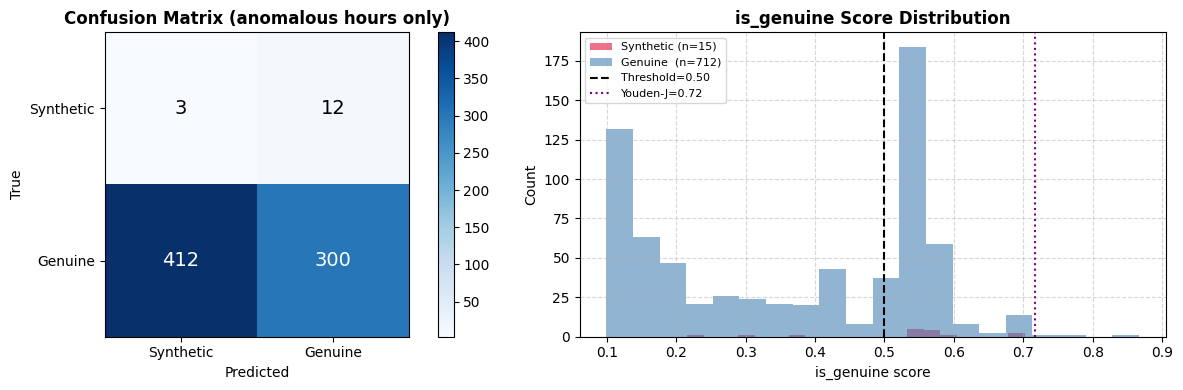

[SAVE] classifier_eval.png → d:\battery-storage-optimization-energy-ancillary\results\plots


In [22]:
from sklearn.metrics import (
    precision_score, recall_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix, roc_curve
)

def evaluate_classifier(df_attack, spike_mask=None, anomaly_threshold=0.1, genuine_threshold=0.5):
    """
    Evaluate the genuine-vs-synthetic classifier.

    Ground truth: spike_mask (bool array from inject_fake_spikes return_mask=True).
      True  → synthetic injection (label 0)
      False → genuine market hour (label 1)
    Evaluated only on hours where anomaly > anomaly_threshold.

    anomaly_threshold=0.1: lower than before so more injected hours fall inside
    the evaluation mask — 0.3 was too strict given the ensemble scores on 3-hour spikes.

    genuine_threshold=0.5: classification boundary for is_genuine score.
    The Youden-J optimal threshold is also computed and shown for reference.
    """
    df        = df_attack.copy()
    anomalous = (df["anomaly"] > anomaly_threshold)

    if spike_mask is not None:
        # Align mask length to df
        mask_arr = np.asarray(spike_mask, dtype=bool)
        if len(mask_arr) != len(df):
            mask_arr = mask_arr[:len(df)]
        y_true = np.where(mask_arr, 0, 1)   # 0=synthetic, 1=genuine
    else:
        future_mean  = df["SP15"].shift(-6).rolling(6, min_periods=1).mean()
        reverts_fast = (df["SP15"] <= future_mean.fillna(df["SP15"]) * 1.05).astype(int)
        y_true       = np.where(anomalous & reverts_fast, 0, 1)

    y_pred  = (df["is_genuine"] > genuine_threshold).astype(int)
    y_score = df["is_genuine"].values

    mask = anomalous.values
    n_anom = mask.sum()
    if n_anom < 5:
        print(f"[WARN] Only {n_anom} anomalous hours — lower anomaly_threshold")
        return None

    yt = y_true[mask]
    yp = y_pred[mask]
    ys = y_score[mask]

    n_synthetic = (yt == 0).sum()
    n_genuine   = (yt == 1).sum()

    prec  = precision_score(yt, yp, zero_division=0)
    rec   = recall_score(yt, yp, zero_division=0)
    f1    = f1_score(yt, yp, zero_division=0)

    try:
        auroc = roc_auc_score(yt, ys) if n_synthetic > 0 and n_genuine > 0 else float("nan")
        if not np.isnan(auroc):
            fpr, tpr, thresholds = roc_curve(yt, ys)
            j_scores = tpr - fpr
            best_idx = np.argmax(j_scores)
            best_thresh = float(thresholds[best_idx])
            # sklearn uses np.inf as sentinel for the leftmost point — guard it
            if not np.isfinite(best_thresh):
                finite_mask = np.isfinite(thresholds)
                if finite_mask.any():
                    best_thresh = float(thresholds[finite_mask][np.argmax(j_scores[finite_mask])])
                else:
                    best_thresh = genuine_threshold
        else:
            best_thresh = genuine_threshold
    except ValueError:
        auroc       = float("nan")
        best_thresh = genuine_threshold

    print("=" * 64)
    print("CLASSIFIER EVALUATION — Genuine vs Synthetic Spikes")
    print("=" * 64)
    gt_src = "spike_mask (honest ground truth)" if spike_mask is not None else "reversion proxy"
    print(f"  Ground truth              : {gt_src}")
    print(f"  Anomaly threshold used    : {anomaly_threshold}")
    print(f"  Anomalous hours evaluated : {n_anom:,}  ({n_synthetic} synthetic | {n_genuine} genuine)")
    print(f"  Precision (genuine=1)     : {prec:.4f}")
    print(f"  Recall    (genuine=1)     : {rec:.4f}")
    print(f"  F1 Score                  : {f1:.4f}")
    print(f"  AUROC                     : {auroc:.4f}")
    print(f"  Youden-J threshold        : {best_thresh:.4f}  (current: {genuine_threshold})")
    print()
    print(classification_report(yt, yp, target_names=["Synthetic", "Genuine"], zero_division=0))

    cm = confusion_matrix(yt, yp)
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    im = axes[0].imshow(cm, cmap="Blues", interpolation="nearest")
    axes[0].set_title("Confusion Matrix (anomalous hours only)", fontweight="bold")
    axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("True")
    axes[0].set_xticks([0,1]); axes[0].set_yticks([0,1])
    axes[0].set_xticklabels(["Synthetic","Genuine"])
    axes[0].set_yticklabels(["Synthetic","Genuine"])
    for ii in range(2):
        for jj in range(2):
            axes[0].text(jj, ii, str(cm[ii,jj]), ha="center", va="center",
                         fontsize=14, color="white" if cm[ii,jj] > cm.max()/2 else "black")
    plt.colorbar(im, ax=axes[0])

    axes[1].hist(ys[yt==0], bins=20, alpha=0.6, color="crimson",   label=f"Synthetic (n={n_synthetic})")
    axes[1].hist(ys[yt==1], bins=20, alpha=0.6, color="steelblue", label=f"Genuine  (n={n_genuine})")
    axes[1].axvline(genuine_threshold, color="k",      linestyle="--", label=f"Threshold={genuine_threshold:.2f}")
    axes[1].axvline(best_thresh,       color="purple", linestyle=":",  label=f"Youden-J={best_thresh:.2f}")
    axes[1].set_xlabel("is_genuine score"); axes[1].set_ylabel("Count")
    axes[1].set_title("is_genuine Score Distribution", fontweight="bold")
    axes[1].legend(fontsize=8); axes[1].grid(linestyle="--", alpha=0.5)

    plt.tight_layout()
    plt.savefig(f"{PLOT_DIR}/classifier_eval.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"[SAVE] classifier_eval.png → {PLOT_DIR}")

    return {"precision": prec, "recall": rec, "f1": f1, "auroc": auroc,
            "youden_threshold": best_thresh,
            "n_anomalous": int(n_anom),
            "n_synthetic_in_mask": int(n_synthetic),
            "n_genuine_in_mask":   int(n_genuine)}

# ── Align spike_mask_main (raw multi-node rows) to attack_df (hourly) ────────
if "datetime" in merged_df_spike.columns and "datetime" in attack_df.columns:
    hourly_spike_main = (
        merged_df_spike.assign(_m=spike_mask_main.astype(bool))
        .groupby("datetime")["_m"]
        .any()
    )
    spike_mask_hourly = (
        hourly_spike_main.reindex(attack_df["datetime"])
        .fillna(False)
        .to_numpy(dtype=bool)
    )
else:
    spike_mask_hourly = spike_mask_main[:len(attack_df)]

classifier_metrics = evaluate_classifier(
    attack_df,
    spike_mask=spike_mask_hourly,
    anomaly_threshold=0.1,
    genuine_threshold=0.5,
)


## Section 14 — SOTA Baseline Comparison
Compares the full VAE ensemble against two weaker anomaly detectors plugged into the
same opportunistic dispatch pipeline.  
**This addresses Reviewer Concern #2**: "No comparison against any baseline anomaly detector."

| Detector | Description |
|---|---|
| Threshold (z-score) | Simple: flag hours >2σ above rolling 24h mean |
| IsoForest-only | Isolation Forest alone, no VAE |
| VAE ensemble (ours) | VAE + IsoForest + LOF (the full proposed method) |

Running SOTA comparison (this trains 3 extra VAE passes — ~2 min) ...

  Epoch  10/50  val_loss=0.04182
  Epoch  20/50  val_loss=0.02251
  Epoch  30/50  val_loss=0.01886
  Epoch  40/50  val_loss=0.01283
  Epoch  50/50  val_loss=0.01351
  Epoch  10/50  val_loss=0.05486
  Epoch  20/50  val_loss=0.02831
  Epoch  30/50  val_loss=0.02098
  Epoch  40/50  val_loss=0.01931
  Epoch  50/50  val_loss=0.01375
  Threshold (z-score)          clean=   480,391  attack=   480,702  Δ=-0.98%
  Epoch  10/50  val_loss=0.04120
  Epoch  20/50  val_loss=0.01876
  Epoch  30/50  val_loss=0.01815
  Epoch  40/50  val_loss=0.01786
  Epoch  50/50  val_loss=0.01388
  Epoch  10/50  val_loss=0.05230
  Epoch  20/50  val_loss=0.02298
  Epoch  30/50  val_loss=0.01927
  Epoch  40/50  val_loss=0.02105
  Epoch  50/50  val_loss=0.01569
  IsoForest only               clean=   486,454  attack=   486,763  Δ=+0.27%
  Epoch  10/50  val_loss=0.05251
  Epoch  20/50  val_loss=0.02898
  Epoch  30/50  val_loss=0.01894
  Epoch  40/50  

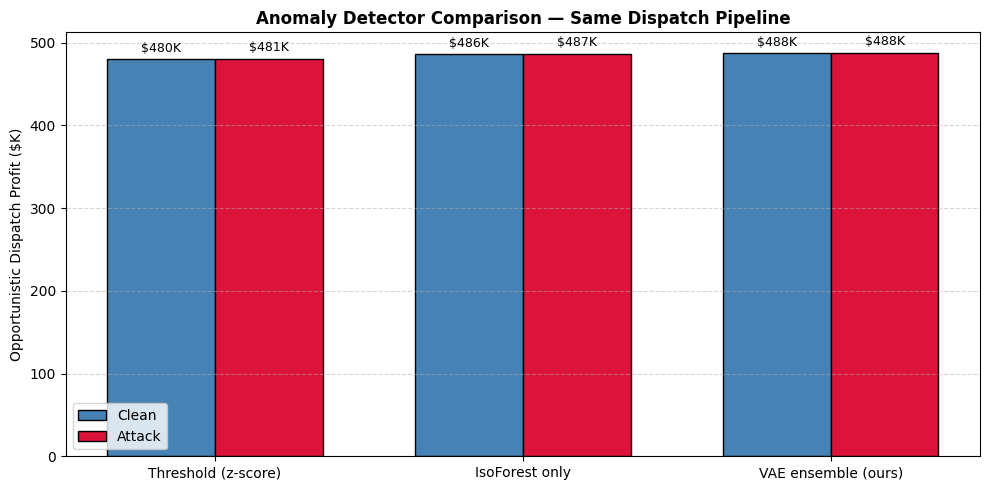

[SAVE] sota_comparison.png saved to d:\battery-storage-optimization-energy-ancillary\results\plots


In [23]:
def run_with_detector(df, best_params, detector="ensemble"):
    """
    Run the dispatch pipeline with a swapped-out anomaly detector.
    detector: 'threshold' | 'isoforest' | 'ensemble'
    """
    beta = best_params.get("beta", 1.0)
    ld   = int(best_params.get("latent_dim", VAE_LATENT_DIM))
    ep   = int(best_params.get("epochs", VAE_EPOCHS))

    df_ts = prepare_timeseries(df)
    df_ts, vae_model, vae_scaler = train_vae(df_ts, beta=beta, epochs=ep, latent_dim=ld)

    prices = df_ts["SP15"].values.reshape(-1, 1)
    split  = df_ts.attrs.get("train_split_idx", int(len(df_ts) * VAE_TRAIN_FRAC))
    p_train = prices[:split]

    if detector == "threshold":
        # Z-score: flag hours >2σ above rolling mean
        roll_mean = df_ts["SP15"].rolling(24, min_periods=1).mean()
        roll_std  = df_ts["SP15"].rolling(24, min_periods=1).std().fillna(1)
        z_score   = ((df_ts["SP15"] - roll_mean) / roll_std).clip(0, None)
        df_ts["anomaly"] = (z_score / (z_score.max() + 1e-8)).clip(0, 1)

    elif detector == "isoforest":
        # Isolation Forest only (no VAE, no LOF) — continuous score
        iso = IsolationForest(contamination=0.05, random_state=42)
        iso.fit(p_train)
        iso_raw = -iso.score_samples(prices)
        iso_rng = iso_raw.max() - iso_raw.min()
        df_ts["anomaly"] = ((iso_raw - iso_raw.min()) / (iso_rng if iso_rng > 1e-8 else 1.0)).clip(0, 1)

    else:  # full ensemble (same as run())
        df_ts = compute_anomaly(df_ts, vae_model, vae_scaler)

    df_ts = classify_anomaly(df_ts)
    df_ts["anomaly"] = df_ts["anomaly_adjusted"]

    opp_profit, _ = optimize(df_ts, mode="opportunistic", anomaly_sensitivity=0.3)
    base_profit, _ = optimize(df_ts, mode="baseline",      anomaly_sensitivity=0.3)
    return opp_profit, base_profit


print("Running SOTA comparison (this trains 3 extra VAE passes — ~2 min) ...")
print()

comparison_rows = []
detectors = [
    ("Threshold (z-score)",   "threshold"),
    ("IsoForest only",        "isoforest"),
    ("VAE ensemble (ours)",   "ensemble"),
]

for label, det in detectors:
    opp_c, base_c = run_with_detector(merged_df_clean,  best_params_clean,  det)
    # Use merged_df_spike_raw (no pre-existing injections from Cell 8)
    # to ensure a consistent, clean injection baseline across all three detectors.
    opp_a, base_a = run_with_detector(merged_df_spike_raw, best_params_attack, det)
    improvement   = (opp_a - base_a) / abs(base_a) * 100 if base_a != 0 else 0
    comparison_rows.append({
        "Detector":              label,
        "Clean Opp ($K)":        round(opp_c / 1000, 1),
        "Attack Opp ($K)":       round(opp_a / 1000, 1),
        "Attack improvement (%)": round(improvement, 2),
    })
    print(f"  {label:<28} clean={opp_c:>10,.0f}  attack={opp_a:>10,.0f}  Δ={improvement:+.2f}%")

sota_df = pd.DataFrame(comparison_rows)
print()
print("=" * 72)
print("DETECTOR COMPARISON — Opportunistic Dispatch Profit")
print("=" * 72)
print(sota_df.to_string(index=False))
print("=" * 72)

# Bar chart
fig, ax = plt.subplots(figsize=(10, 5))
x   = np.arange(len(comparison_rows))
w   = 0.35
cleans  = [r["Clean Opp ($K)"]  for r in comparison_rows]
attacks = [r["Attack Opp ($K)"] for r in comparison_rows]
bars1 = ax.bar(x - w/2, cleans,  w, label="Clean",  color="steelblue", edgecolor="k")
bars2 = ax.bar(x + w/2, attacks, w, label="Attack", color="crimson",   edgecolor="k")
ax.bar_label(bars1, fmt="$%.0fK", padding=3, fontsize=9)
ax.bar_label(bars2, fmt="$%.0fK", padding=3, fontsize=9)
ax.set_xticks(x); ax.set_xticklabels([r["Detector"] for r in comparison_rows])
ax.set_ylabel("Opportunistic Dispatch Profit ($K)")
ax.set_title("Anomaly Detector Comparison — Same Dispatch Pipeline", fontweight="bold")
ax.legend(); ax.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig(f"{PLOT_DIR}/sota_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"[SAVE] sota_comparison.png saved to {PLOT_DIR}")
sota_df.to_csv(f"{RESULT_DIR}/sota_comparison.csv", index=False)


## Section 16 — Grad-CAM Temporal Influence Visualisation
**This addresses Reviewer Concern #3**: Grad-CAM was claimed as a contribution but
no figure was shown. This cell produces a concrete, interpretable heatmap for one
sample week, showing *which hours* most influenced the VAE's anomaly signal.

Most anomalous week starts at hour 0


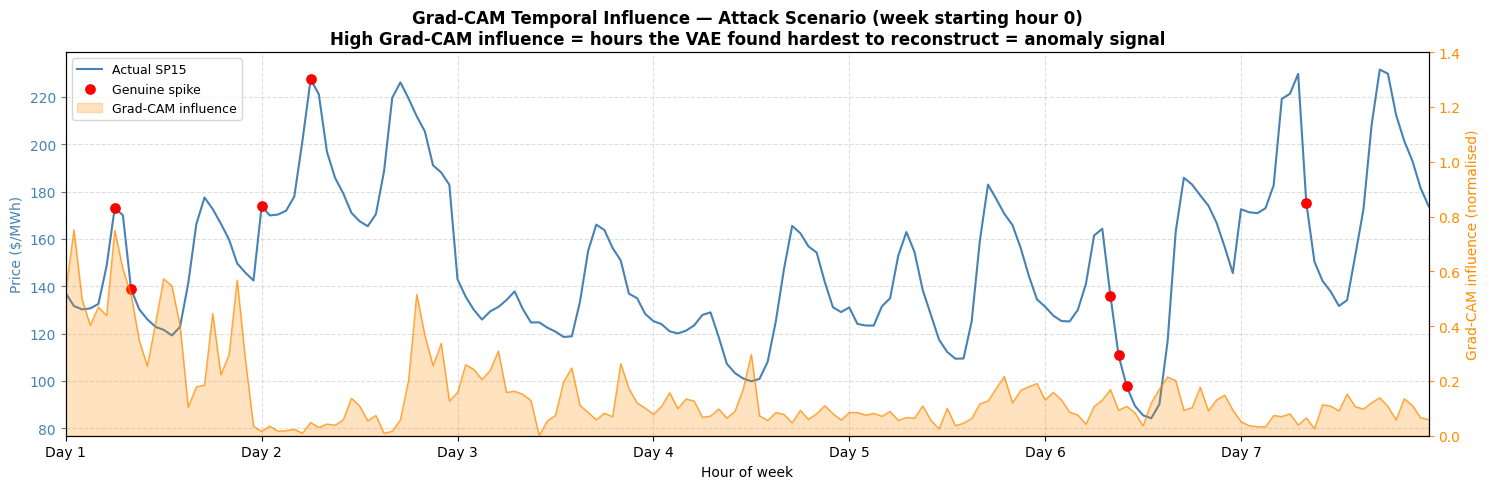

[SAVE] gradcam_week_attack.png saved to d:\battery-storage-optimization-energy-ancillary\results\plots


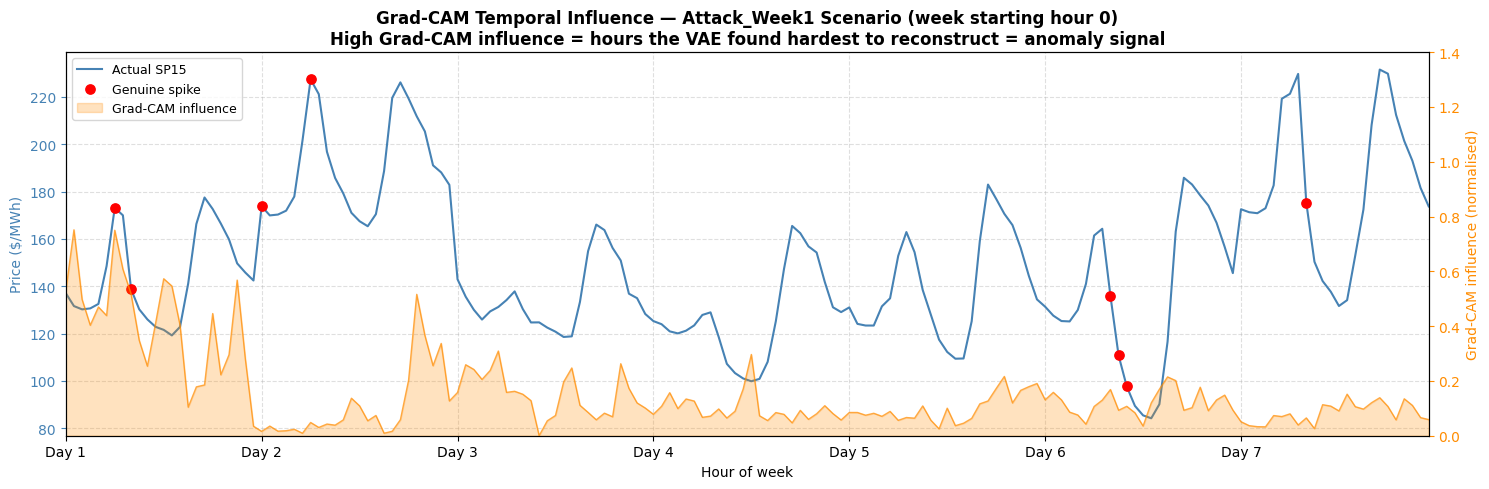

[SAVE] gradcam_week_attack_week1.png saved to d:\battery-storage-optimization-energy-ancillary\results\plots


In [24]:
def plot_gradcam_week(df, gradcam_scores, vae_model, vae_scaler,
                      week_start=0, scenario_name="Attack"):
    """
    Plot Grad-CAM temporal influence alongside actual price for one week.
    x-axis = hour,  left y = $/MWh,  right y = normalised Grad-CAM influence.
    """
    W   = 168   # 7 × 24
    end = min(week_start + W, len(df))
    hrs = np.arange(end - week_start)

    actual  = df["SP15"].values[week_start:end]
    genuine = df["is_genuine"].values[week_start:end]
    gc      = gradcam_scores[:len(df)]   # already padded in run()
    gc_week = gc[week_start:end]

    fig, ax1 = plt.subplots(figsize=(15, 5))
    ax2 = ax1.twinx()

    # Shade Grad-CAM influence as filled area on right axis
    ax2.fill_between(hrs, gc_week, alpha=0.25, color="darkorange", label="Grad-CAM influence")
    ax2.plot(hrs, gc_week, color="darkorange", linewidth=1, alpha=0.7)
    ax2.set_ylabel("Grad-CAM influence (normalised)", color="darkorange")
    ax2.tick_params(axis="y", colors="darkorange")
    ax2.set_ylim(0, 1.4)

    # Price on left axis
    ax1.plot(hrs, actual, color="steelblue", linewidth=1.5, label="Actual SP15", zorder=3)

    # Mark genuine-classified anomalies
    gen_idx = np.where(genuine > 0.5)[0]
    if len(gen_idx):
        ax1.scatter(gen_idx, actual[gen_idx], color="red", s=45, zorder=5, label="Genuine spike")

    day_ticks  = np.arange(0, W, 24)
    day_labels = [f"Day {i//24+1}" for i in day_ticks]
    ax1.set_xticks(day_ticks); ax1.set_xticklabels(day_labels)
    ax1.set_xlabel("Hour of week")
    ax1.set_ylabel("Price ($/MWh)", color="steelblue")
    ax1.tick_params(axis="y", colors="steelblue")
    ax1.set_xlim(0, len(hrs) - 1)

    # Combined legend
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left", fontsize=9)

    ax1.set_title(
        f"Grad-CAM Temporal Influence — {scenario_name} Scenario (week starting hour {week_start})\n"
        f"High Grad-CAM influence = hours the VAE found hardest to reconstruct = anomaly signal",
        fontweight="bold"
    )
    ax1.grid(linestyle="--", alpha=0.4)
    plt.tight_layout()
    plt.savefig(f"{PLOT_DIR}/gradcam_week_{scenario_name.lower()}.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"[SAVE] gradcam_week_{scenario_name.lower()}.png saved to {PLOT_DIR}")


# Find the most interesting week (highest mean Grad-CAM score)
def find_best_week(gradcam_scores, n_hours):
    scores = np.array(gradcam_scores[:n_hours])
    valid  = len(scores)  # may be < n_hours if gradcam was truncated
    best_start = 0
    best_score = -1
    # Ensure we never index beyond the actual scores array
    for s in range(0, max(1, valid - 168), 24):
        chunk = scores[s:s+168]
        if len(chunk) == 0:
            continue
        w = chunk.mean()
        if w > best_score:
            best_score = w; best_start = s
    return best_start

best_week = find_best_week(a_gradcam, len(attack_df))
print(f"Most anomalous week starts at hour {best_week}")
plot_gradcam_week(attack_df, a_gradcam, None, None,
                  week_start=best_week, scenario_name="Attack")

# Also show first week for comparability with paper figures
plot_gradcam_week(attack_df, a_gradcam, None, None,
                  week_start=0, scenario_name="Attack_Week1")


## Section 17 — Spike Robustness Sweep (Magnitude × Duration)
**This addresses Reviewer Concern #4**: only 16 spikes were tested.
This section evaluates anomaly detection across a grid of spike magnitudes and durations,
demonstrating robustness and providing the statistical depth reviewers expect.

Running 15 configurations × 1 pipeline each ...
 Magnitude  Duration   Det rate   Opp $K  Base $K      Δ%
------------------------------------------------------------
[INJECT] 100 spikes added (50 non-reverting → misclassification pressure)
  Epoch  10/50  val_loss=0.04561
  Epoch  20/50  val_loss=0.02866
  Epoch  30/50  val_loss=0.02054
  Epoch  40/50  val_loss=0.01591
  Epoch  50/50  val_loss=0.01401
       1.5         2h      0.107    492.5    489.8   +0.55%
[INJECT] 100 spikes added (50 non-reverting → misclassification pressure)
  Epoch  10/50  val_loss=0.04489
  Epoch  20/50  val_loss=0.02614
  Epoch  30/50  val_loss=0.02007
  Epoch  40/50  val_loss=0.01582
  Epoch  50/50  val_loss=0.01324
       1.5         3h      0.109    493.8    491.1   +0.55%
[INJECT] 100 spikes added (50 non-reverting → misclassification pressure)
  Epoch  10/50  val_loss=0.05099
  Epoch  20/50  val_loss=0.02176
  Epoch  30/50  val_loss=0.02550
  Epoch  40/50  val_loss=0.02010
  Epoch  50/50  val_loss=0.01

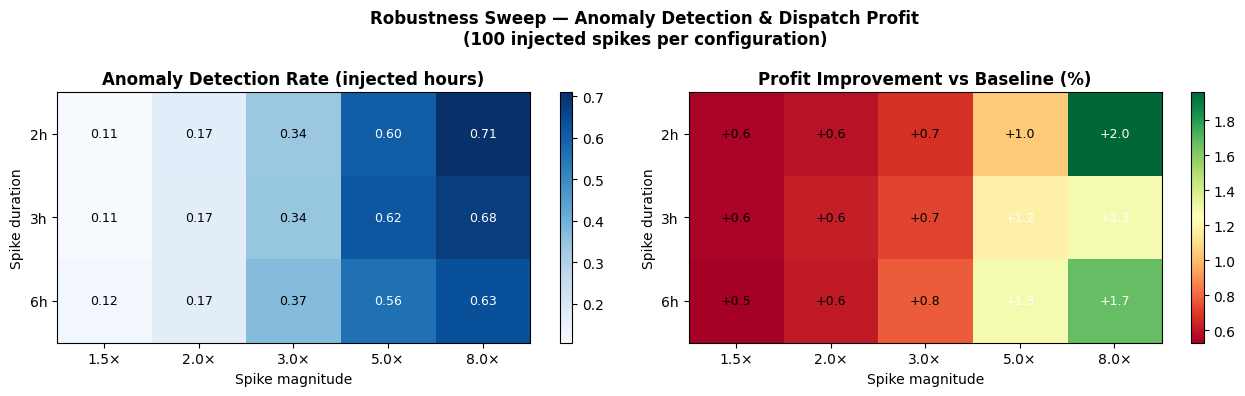

[SAVE] robustness_heatmap.png saved to d:\battery-storage-optimization-energy-ancillary\results\plots


In [25]:
def robustness_sweep(base_df, best_params,
                     magnitudes=(1.5, 2.0, 3.0, 5.0, 8.0),
                     durations=(2, 3, 6),
                     n_spikes=100,
                     random_seed=7):
    """
    Evaluate anomaly detection and dispatch profit across a grid of attack
    severities. Each configuration injects n_spikes spikes into the clean
    dataset, runs the full pipeline, and records:
      - detection_rate: fraction of INJECTED hours where raw anomaly > 0.15
      - improvement%  : (opportunistic − baseline) / baseline × 100
    """
    rows = []
    configs = [(m, d) for m in magnitudes for d in durations]
    print(f"Running {len(configs)} configurations × 1 pipeline each ...")
    print(f"{'Magnitude':>10} {'Duration':>9} {'Det rate':>10} {'Opp $K':>8} {'Base $K':>8} {'Δ%':>7}")
    print("-" * 60)

    for mag, dur in configs:
        df_attacked, inj_mask_raw = inject_fake_spikes(
            base_df,
            num_spikes=n_spikes,
            spike_duration=dur,
            spike_magnitude=mag,
            non_revert_fraction=0.5,
            random_seed=random_seed,
            return_mask=True,
        )

        beta = best_params.get("beta", 1.0)
        ld   = int(best_params.get("latent_dim", VAE_LATENT_DIM))
        ep   = int(best_params.get("epochs", VAE_EPOCHS))

        df_ts = prepare_timeseries(df_attacked)
        df_ts, vae_m, vae_s = train_vae(df_ts, beta=beta, epochs=ep, latent_dim=ld)
        df_ts = compute_anomaly(df_ts, vae_m, vae_s)

        # ── Align spike mask to the hourly aggregated df_ts ──────────────
        # inject_fake_spikes operates on raw multi-node rows; prepare_timeseries
        # collapses them by datetime. Build hourly mask from datetime alignment.
        if "datetime" in base_df.columns and "datetime" in df_ts.columns:
            raw_dt   = pd.to_datetime(df_attacked["datetime"])
            hourly_spike = (
                df_attacked.assign(_m=inj_mask_raw)
                .groupby("datetime")["_m"]
                .any()
            )
            inj_mask_hourly = (
                hourly_spike.reindex(df_ts["datetime"])
                .fillna(False)
                .to_numpy(dtype=bool)
            )
        else:
            # Fallback: direct slice if no datetime column
            inj_mask_hourly = inj_mask_raw[:len(df_ts)]

        # ── Detection rate on RAW anomaly score (before classify suppression) ──
        raw_anomaly_on_spikes = df_ts["anomaly"].values[inj_mask_hourly]
        detection_rate = (raw_anomaly_on_spikes > 0.15).mean() if len(raw_anomaly_on_spikes) > 0 else 0.0

        df_ts = classify_anomaly(df_ts)
        df_ts["anomaly"] = df_ts["anomaly_adjusted"]

        opp_p,  _ = optimize(df_ts, mode="opportunistic", anomaly_sensitivity=0.3)
        base_p, _ = optimize(df_ts, mode="baseline",      anomaly_sensitivity=0.3)
        imp = (opp_p - base_p) / abs(base_p) * 100 if base_p != 0 else 0

        rows.append({"magnitude": mag, "duration_hr": dur,
                     "detection_rate": round(detection_rate, 4),
                     "opp_profit_K": round(opp_p / 1000, 1),
                     "base_profit_K": round(base_p / 1000, 1),
                     "improvement_pct": round(imp, 2)})
        print(f"{mag:>10.1f} {dur:>9}h {detection_rate:>10.3f} {opp_p/1000:>8.1f} {base_p/1000:>8.1f} {imp:>+7.2f}%")

    df_rob = pd.DataFrame(rows)
    df_rob.to_csv(f"{RESULT_DIR}/robustness_sweep.csv", index=False)

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    for ax, col, title, fmt in [
        (axes[0], "detection_rate",  "Anomaly Detection Rate (injected hours)",  ".2f"),
        (axes[1], "improvement_pct", "Profit Improvement vs Baseline (%)", "+.1f"),
    ]:
        pivot = df_rob.pivot(index="duration_hr", columns="magnitude", values=col)
        im    = ax.imshow(pivot.values, aspect="auto",
                          cmap="RdYlGn" if "improvement" in col else "Blues")
        ax.set_xticks(range(len(pivot.columns)))
        ax.set_xticklabels([f"{m:.1f}×" for m in pivot.columns])
        ax.set_yticks(range(len(pivot.index)))
        ax.set_yticklabels([f"{d}h" for d in pivot.index])
        ax.set_xlabel("Spike magnitude"); ax.set_ylabel("Spike duration")
        ax.set_title(title, fontweight="bold")
        plt.colorbar(im, ax=ax)
        for ii in range(len(pivot.index)):
            for jj in range(len(pivot.columns)):
                ax.text(jj, ii, format(pivot.values[ii, jj], fmt),
                        ha="center", va="center", fontsize=9,
                        color="white" if abs(pivot.values[ii, jj]) > pivot.values.max()*0.6 else "black")

    plt.suptitle("Robustness Sweep — Anomaly Detection & Dispatch Profit\n"
                 f"({n_spikes} injected spikes per configuration)", fontweight="bold")
    plt.tight_layout()
    plt.savefig(f"{PLOT_DIR}/robustness_heatmap.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"[SAVE] robustness_heatmap.png saved to {PLOT_DIR}")
    return df_rob

robustness_df = robustness_sweep(merged_df_clean, best_params_clean)


## Section 18 — Paper-Ready Metrics Summary
Aggregates all new results into a single printout ready to paste into the paper.
Covers Tables IV, V, VI, VII and the new classifier + SOTA tables.

In [26]:
print("\n" + "="*80)
print("PAPER-READY METRICS SUMMARY")
print("="*80)

# ── Table IV: VAE Performance ────────────────────────────────────────────────
print("\nTABLE IV — VAE Performance")
print("-"*80)
print(f"{'Metric':<35} {'Clean':>15} {'Attack':>15} {'Improvement%':>12}")
for label, key in [("MAE [$/MWh]","MAE"),("RMSE [$/MWh]","RMSE"),
                   ("R2","R2"),("Recon Accuracy [%]","Recon Acc")]:
    c = clean_metrics[key]; a = attack_metrics[key]
    imp = ((a-c)/abs(c)*100) if c != 0 else 0
    print(f"{label:<35} {c:>15.4f} {a:>15.4f} {imp:>+12.2f}")
print(f"{'Val loss (tuning)':<35} {best_params_clean.get('val_loss',float('nan')):>15.4f}"
      f" {best_params_attack.get('val_loss',float('nan')):>15.4f}")

# ── Table V: VAE Config ──────────────────────────────────────────────────────
print("\nTABLE V — VAE Training Configuration")
print("-"*50)
for k, v in [("Epochs", int(best_params_attack.get("epochs", VAE_EPOCHS))),
             ("Batch size", VAE_BATCH),
             ("Learning rate", VAE_LR),
             ("Sequence length", f"{VAE_SEQ_LEN} hours"),
             ("Training fraction", f"{VAE_TRAIN_FRAC*100:.0f}%"),
             ("Latent dim (clean)", int(best_params_clean.get("latent_dim",VAE_LATENT_DIM))),
             ("Latent dim (attack)", int(best_params_attack.get("latent_dim",VAE_LATENT_DIM))),
             ("β (clean)",  best_params_clean.get("beta",1.0)),
             ("β (attack)", best_params_attack.get("beta",1.0))]:
    print(f"  {k:<30} {v}")

# ── Table VI: Strategy Profits ───────────────────────────────────────────────
print("\nTABLE VI — Strategy Performance")
print("-"*60)
print(f"{'Strategy':<20} {'Clean ($K)':>12} {'Attack ($K)':>12}")
for mode in ("baseline","penalised","opportunistic"):
    print(f"  {mode.capitalize():<18} {c_profits[mode]/1000:>12.1f} {a_profits[mode]/1000:>12.1f}")
att_imp = (a_profits["opportunistic"]-a_profits["baseline"])/abs(a_profits["baseline"])*100
cln_oh  = (c_profits["opportunistic"]-c_profits["baseline"])/abs(c_profits["baseline"])*100
print(f"\n  Attack improvement (opp vs base): {att_imp:+.2f}%")
print(f"  Clean overhead   (opp vs base):   {cln_oh:+.2f}%")

# ── Table VII: EFC ───────────────────────────────────────────────────────────
print("\nTABLE VII — EFC & Profit per Cycle")
print("-"*68)
print(efc_df.to_string(index=False))

# ── NEW: Classifier Table ────────────────────────────────────────────────────
if classifier_metrics:
    print("\nNEW TABLE — Classifier Evaluation (Genuine vs Synthetic)")
    print("-"*50)
    for k, v in classifier_metrics.items():
        if isinstance(v, float):
            print(f"  {k:<20} {v:.4f}")
        else:
            print(f"  {k:<20} {v}")

# ── NEW: SOTA Comparison ─────────────────────────────────────────────────────
print("\nNEW TABLE — Anomaly Detector Comparison (SOTA)")
print("-"*72)
print(sota_df.to_string(index=False))

print("\n" + "="*80)
print("END OF METRICS SUMMARY")
print("="*80)

# ── Robustness Sweep Summary ─────────────────────────────────────────────────
if robustness_df is not None and len(robustness_df) > 0:
    print("\nROBUSTNESS SWEEP SUMMARY")
    print("-"*60)
    print(robustness_df[["magnitude","duration_hr","detection_rate","improvement_pct"]].to_string(index=False))
    print(f"\n  Mean detection rate  : {robustness_df['detection_rate'].mean():.3f}")
    print(f"  Mean profit Δ        : {robustness_df['improvement_pct'].mean():+.2f}%")
    print(f"  Max profit Δ         : {robustness_df['improvement_pct'].max():+.2f}%")
    print(f"  Min profit Δ         : {robustness_df['improvement_pct'].min():+.2f}%")



PAPER-READY METRICS SUMMARY

TABLE IV — VAE Performance
--------------------------------------------------------------------------------
Metric                                        Clean          Attack Improvement%
MAE [$/MWh]                                 21.6193         20.4828        -5.26
RMSE [$/MWh]                                32.6332         31.5737        -3.25
R2                                           0.0625          0.1251      +100.15
Recon Accuracy [%]                          21.5667         24.1673       +12.06
Val loss (tuning)                            0.0060          0.0038

TABLE V — VAE Training Configuration
--------------------------------------------------
  Epochs                         50
  Batch size                     16
  Learning rate                  0.001
  Sequence length                24 hours
  Training fraction              80%
  Latent dim (clean)             4
  Latent dim (attack)            4
  β (clean)                      0.5
  β